In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
df=pd.read_csv("../Data/final/environment_data.csv")
df

,City,Date,PM2.5,PM10,O3,NO2,CO,SO2,Green_Space,Temperature_mean,Temperature_max,Humidity,Wind_speed,Pressure,Electricity Consumption,Source,isWeekend,Season
0,Cairo,2023-01-01,36.337500,60.341667,33.333333,36.100000,337.416667,34.795833,53,15.888889,20.0,75.333333,8.511111,1007.247111,3.583944e+08,estimated,1,Winter
1,Cairo,2023-01-02,49.379167,78.937500,18.625000,46.704167,442.000000,55.141667,53,16.044444,21.0,70.844444,7.888889,1006.393556,4.010897e+08,estimated,1,Winter
2,Cairo,2023-01-03,34.066667,51.825000,24.583333,44.612500,387.041667,48.670833,53,15.288889,19.0,75.911111,6.644444,1006.458667,4.154422e+08,estimated,1,Winter
3,Cairo,2023-01-04,30.737500,43.029167,38.958333,37.420833,322.166667,42.025000,53,15.777778,19.0,78.377778,7.022222,1007.377111,4.332206e+08,estimated,1,Winter
4,Cairo,2023-01-05,23.145833,34.125000,29.041667,48.162500,415.166667,50.412500,53,16.136364,19.0,61.795455,5.704545,1008.101818,4.017179e+08,estimated,1,Winter
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2543,Nairobi,2023-12-25,9.741667,14.033333,48.666667,4.825000,290.500000,2.916667,62,20.880000,26.0,80.360000,17.360000,839.280000,6.992102e+07,estimated,1,Winter
2544,Nairobi,2023-12-26,8.929167,12.904167,46.875000,3.945833,265.375000,2.533333,62,19.320000,24.0,85.260000,21.020000,838.910000,6.672389e+07,estimated,1,Winter
2545,Nairobi,2023-12-27,9.725000,14.341667,54.916667,4.812500,283.875000,2.570833,62,19.630000,25.0,71.220000,19.590000,839.930000,7.134523e+07,estimated,1,Winter
2546,Nairobi,2023-12-28,11.516667,16.700000,54.791667,6.679167,341.708333,3.412500,62,20.370000,26.0,69.160000,13.810000,840.210000,6.755095e+07,estimated,1,Winter


In [26]:
pollutant = df[['PM2.5','PM10','O3','NO2','CO','SO2']]
pollutant

,PM2.5,PM10,O3,NO2,CO,SO2
0,36.337500,60.341667,33.333333,36.100000,337.416667,34.795833
1,49.379167,78.937500,18.625000,46.704167,442.000000,55.141667
2,34.066667,51.825000,24.583333,44.612500,387.041667,48.670833
3,30.737500,43.029167,38.958333,37.420833,322.166667,42.025000
4,23.145833,34.125000,29.041667,48.162500,415.166667,50.412500
...,...,...,...,...,...,...
2543,9.741667,14.033333,48.666667,4.825000,290.500000,2.916667
2544,8.929167,12.904167,46.875000,3.945833,265.375000,2.533333
2545,9.725000,14.341667,54.916667,4.812500,283.875000,2.570833
2546,11.516667,16.700000,54.791667,6.679167,341.708333,3.412500


In [27]:
means = df.groupby('isWeekend')[pollutant.columns].mean()

means.index = ['Weekend', 'Weekday']
print(means)

             PM2.5       PM10         O3        NO2          CO        SO2
Weekend  19.799664  35.861166  55.263053  31.744340  334.224521  14.069140
Weekday  20.666187  37.538924  54.240919  33.723271  340.303385  14.619999


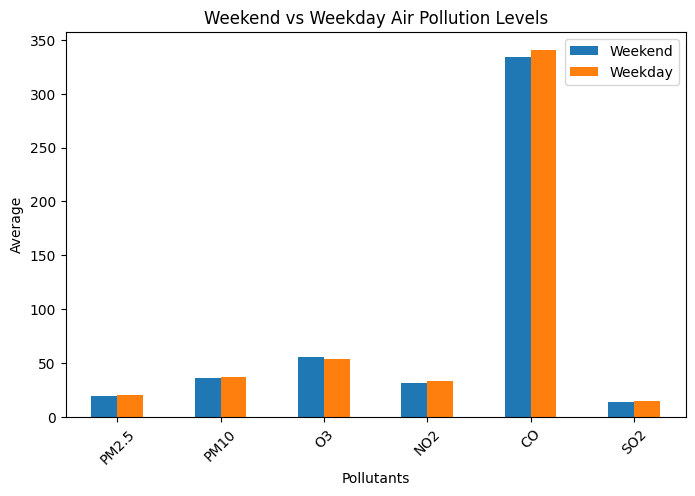

In [29]:
means.T.plot(kind='bar', figsize=(8,5))

plt.title('Weekend vs Weekday Air Pollution Levels')
plt.xlabel('Pollutants')
plt.ylabel('Average')
plt.xticks(rotation=45)
plt.show()

The 'means' variable calculates the average of each pollutant, and is grouped by the unique values found in the 'isWeekend' column (1 for weekdays and 0 for weekends). The bar plot visualizes what was stated before, and it shows that the air pollution does not vary significantly whether it is weekday or weekend.

In [16]:
normalized = []

for n in pollutant:
    x_min = df[n].min()
    x_max = df[n].max()

    if x_min != x_max:
        normalized_values = (df[n]-x_min) / (x_max - x_min)
    else:
        normalized_values = 0

    normalized.append(normalized_values)


print(normalized)

[0       0.376442
1       0.523211
2       0.350886
3       0.313420
4       0.227985
          ...   
2543    0.077136
2544    0.067992
2545    0.076948
2546    0.097112
2547    0.093501
Name: PM2.5, Length: 2548, dtype: float64, 0       0.163039
1       0.217010
2       0.138321
3       0.112792
4       0.086949
          ...   
2543    0.028636
2544    0.025359
2545    0.029531
2546    0.036376
2547    0.034961
Name: PM10, Length: 2548, dtype: float64, 0       0.145794
1       0.078607
2       0.105824
3       0.171488
4       0.126190
          ...   
2543    0.215836
2544    0.207651
2545    0.244385
2546    0.243814
2547    0.238104
Name: O3, Length: 2548, dtype: float64, 0       0.191870
1       0.251260
2       0.239545
3       0.199267
4       0.259428
          ...   
2543    0.016709
2544    0.011785
2545    0.016639
2546    0.027093
2547    0.023476
Name: NO2, Length: 2548, dtype: float64, 0       0.088742
1       0.129755
2       0.108203
3       0.082761
4       0.119232


In [17]:
NPI = sum(normalized)/len(normalized)
print(NPI)

0       0.197694
1       0.258278
2       0.208567
3       0.191006
4       0.189916
          ...   
2543    0.070993
2544    0.064689
2545    0.075057
2546    0.085879
2547    0.083314
Length: 2548, dtype: float64


In [19]:
weekday_NPI = NPI[df['isWeekend'] == 1]

weekend_NPI = NPI[df['isWeekend'] == 0]

values = [weekday_NPI.mean(), weekend_NPI.mean()]

Each pollutant has a different scale and unit, so normalization is used to create one combined pollution index in which all pollutants contribute fairly. The NPI (normalized pollution index) variable computes a single combined pollution index by averaging all the normalized pollutants together.

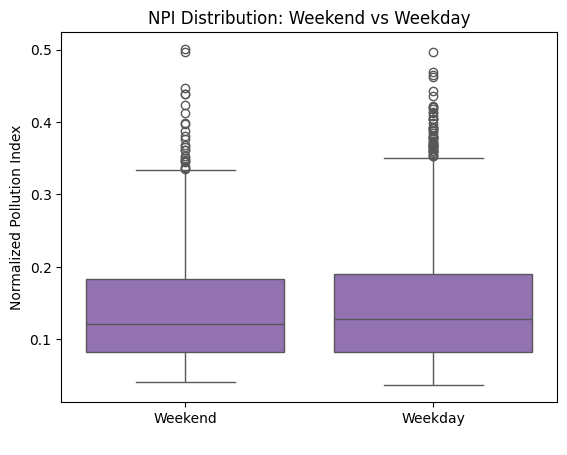

In [23]:
base_color = sns.color_palette()[4]

sns.boxplot(x = df['isWeekend'], y = NPI, color = base_color)

plt.xticks([0, 1], ['Weekend', 'Weekday'])
plt.title("NPI Distribution: Weekend vs Weekday")
plt.ylabel("Normalized Pollution Index")
plt.xlabel(" ")
plt.show()

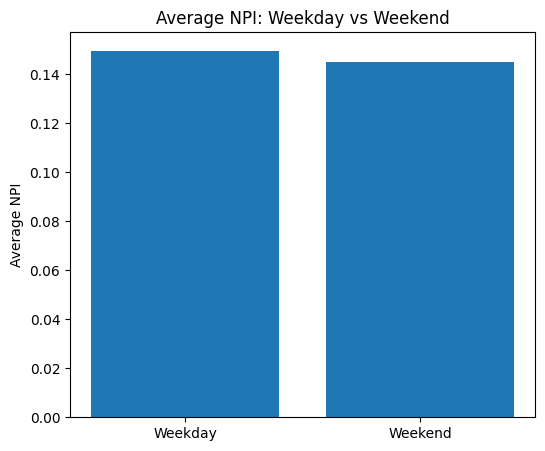

In [24]:
plt.figure(figsize=(6,5))

plt.bar(['Weekday','Weekend'], values)

plt.title("Average NPI: Weekday vs Weekend")
plt.ylabel("Average NPI")

plt.show()

The boxplot indicates that pollution levels are generally lower and more stable on weekends, as seen by the reduced median and shorter top whisker compared to weekdays. While both periods experience sudden spikes, the weekday data shows a denser cluster of extreme outliers, suggesting a higher frequency of severe pollution events during the work week (more "volatile" and prone to dangerous pollution spikes).

Overall, this pattern confirms air quality improves on the weekends when industrial activity and commuter traffic decline.

The bar chart shows that average pollution levels are slightly lower on weekends compared to weekdays. It reinforces what is shown in the boxplot.